1.为了较好的操作，首先会导入一些列必须的包并定义必要的函数

In [1]:
import pandas as pd
from warnings import filterwarnings
import random

import torch.cuda as cuda
from scipy.sparse import csr_matrix

from scformer.model import *
from scformer.utils import *

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

2.数据太大了，模型训练太慢，我会在这里创建一个比较小的数据集

In [2]:
# 加载表达矩阵
expression_matrix = pd.read_csv("data/mouse_retina/expression_matrix.csv", index_col=0)
expression_matrix_ = csr_matrix(expression_matrix)

# 创建AnnData对象
adata = sc.AnnData(expression_matrix_.transpose())

# 添加基因和细胞的名称
adata.var_names = expression_matrix.index  # 基因名称
adata.obs_names = expression_matrix.columns  # 细胞名称

# 加载细胞元数据
cell_metadata = pd.read_csv("data/mouse_retina/cell_metadata.csv", index_col=0)

# 将元数据添加到AnnData对象中
adata.obs = cell_metadata
adata

AnnData object with n_obs × n_vars = 9383 × 6275
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'

In [3]:
# adata_151673 = sc.read_10x_mtx('data/DLPFC/151673/filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
# metadata = pd.read_csv('data/DLPFC/151673/metadata.csv')
# adata_151673.obs = metadata
# adata_151673.var_names_make_unique()
#
# adata_151674 = sc.read_10x_mtx('data/DLPFC/151672/filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
# metadata = pd.read_csv('data/DLPFC/151672/metadata.tsv')
# adata_151674.obs = metadata
# adata_151674.var_names_make_unique()
#
# adata_151673.obs['batch'] = 1
# adata_151674.obs['batch'] = 2
# adata = sc.concat([adata_151673, adata_151674], join='outer', label='batch', keys=['batch1', 'batch2'])

In [4]:
# batch_labels_list = adata.obs['batch']
batch_labels_list = None

In [5]:
selected_indices = np.random.choice(adata.n_obs, size=500, replace=False)
adata_subset = adata[selected_indices].copy()
# adata_subset = adata

In [6]:
# adata_subset.raw = adata_subset.copy()
# sc.pp.normalize_total(adata_subset, target_sum=1e4)
# sc.pp.log1p(adata_subset)
# sc.pp.scale(adata_subset, zero_center=True)
# sc.tl.pca(adata, svd_solver="arpack")
# sc.pp.neighbors(adata_subset)
# sc.tl.leiden(adata_subset)
# sc.tl.umap(adata_subset)
# # sc.pl.umap(adata_subset, color=['leiden', 'ground_truth', 'batch'], show=True)
# sc.pl.umap(adata_subset, color=["celltype", "leiden"], show=True)

In [7]:
# adata_subset.X = csr_matrix(adata_subset.X)

In [8]:
RNA_matrix = adata_subset.X.transpose()

In [9]:
cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

cell_size = 30

initial_pre = initial_clustering(RNA_matrix)
# initial_pre = initial_clustering(adata_subset.raw.X)

cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix, cell_size=cell_size)
n_batch = len(indices)

output_file = 'data/DLPFC/output/different_samples_1'
os.makedirs(output_file, exist_ok=True)
# np.save(output_file + "/Node_Ids.npy", Node_Ids)

device = torch.device("cuda" if cuda.is_available() else "cpu")

node_model = NDR_1(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                   n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                   num_relations=2, epochs=100, loss_contrastive_weight=0.001)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch, batch_labels_list=batch_labels_list)
# node_model.save_model('new_model_1.pth')

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.
正在将数据划分为批次并进行并行处理。请稍候...


处理批次: 100%|██████████| 17/17 [00:06<00:00,  2.54it/s]


The training process for the NodeDimensionReduction model has started. Please wait.


Epochs: 100%|██████████| 100/100 [01:19<00:00,  1.26it/s]

The training for the NodeDimensionReduction model has been completed.


In [10]:
ScFormer_result = ScFormer_pred(
    RNA_matrix, gnn=gnn, indices=indices, device=device
)
# Save numpy arrays to files
output_file = "data/mouse_retina/output"
np.save(output_file + "/Node_Ids.npy", Node_Ids)
np.save(output_file + "/pred.npy", ScFormer_result["pred_label"])
np.save(output_file + "/cell_embedding.npy", ScFormer_result["cell_embedding"])

Prediction Batches: 100%|██████████| 17/17 [00:00<00:00, 51.25it/s]


In [11]:
node_ids = np.load("data/mouse_retina/output/node_ids.npy")
cell_emb = np.load("data/mouse_retina/output/cell_embedding.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata_subset.obsm['cell_emb'] = cell_emb_sorted.values

In [12]:
pred = np.load(output_file + '/pred.npy')
pred_ = pd.DataFrame(pred, index=Node_Ids)
pred_sorted = pred_.sort_index()
adata_subset.obs['pre'] = pred_sorted.values
adata_subset.obs['pre'] = adata_subset.obs['pre'].astype('category')

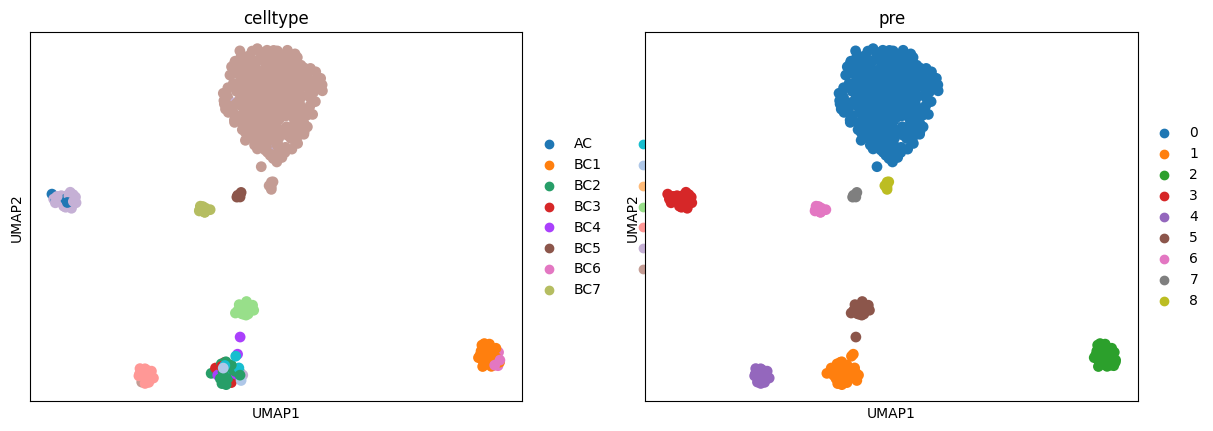

In [13]:
adata_subset.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata_subset, use_rep="cell_emb")
sc.tl.umap(adata_subset)
sc.pl.umap(adata_subset, color=["celltype", "pre"], show=True)
# sc.pl.umap(adata_subset, color=['ground_truth', 'batch'], show=True)